In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
import numpy as np

In [2]:
data = pd.read_csv("spambase.data", header = None)

In [3]:
X = data.iloc[:, :-1]
y = data.iloc[:, -1]

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size = 0.25, 
    random_state = 42, 
    stratify = y
)

## Problem 1

### Part 1

In [5]:
decisionTree = DecisionTreeClassifier(criterion = "entropy", random_state = 42)

In [6]:
decisionTree.fit(X_train, y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [7]:
y_train_pred = decisionTree.predict(X_train)
y_test_pred = decisionTree.predict(X_test)

In [8]:
# accuracy
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

In [9]:
# error
train_error = 1 - train_acc
test_error = 1 - test_acc

In [10]:
# F1
train_f1 = f1_score(y_train, y_train_pred)
test_f1 = f1_score(y_test, y_test_pred)

In [11]:
# AUC
y_train_prob = decisionTree.predict_proba(X_train)[:, 1]
y_test_prob = decisionTree.predict_proba(X_test)[:, 1]

train_auc = roc_auc_score(y_train, y_train_prob)
test_auc = roc_auc_score(y_test, y_test_prob)

In [12]:
# print error, accuracy, f1, AUC
print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)
print()

print("Train Error:", train_error)
print("Test Error:", test_error)
print()

print("Train F1 Score:", train_f1)
print("Test F1 Score:", test_f1)
print()

print("Train AUC:", train_auc)
print("Test AUC:", test_auc)

Train Accuracy: 0.9997101449275362
Test Accuracy: 0.9218071242397915

Train Error: 0.00028985507246381825
Test Error: 0.0781928757602085

Train F1 Score: 0.9996319470003681
Test F1 Score: 0.9015317286652079

Train AUC: 0.9999998240470653
Test AUC: 0.9193112078827448


### Part 2

In [13]:
decisionTreeGini = DecisionTreeClassifier(criterion = "gini", random_state = 42)

In [14]:
decisionTreeGini.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [15]:
y_train_pred_gini = decisionTreeGini.predict(X_train)
y_test_pred_gini = decisionTreeGini.predict(X_test)

In [16]:
# accuracy
train_acc_gini = accuracy_score(y_train, y_train_pred_gini)
test_acc_gini = accuracy_score(y_test, y_test_pred_gini)

In [17]:
# error
train_error_gini = 1 - train_acc_gini
test_error_gini = 1 - test_acc_gini

In [18]:
# F1
train_f1_gini = f1_score(y_train, y_train_pred_gini)
test_f1_gini = f1_score(y_test, y_test_pred_gini)

In [19]:
# AUC
y_train_prob_gini = decisionTreeGini.predict_proba(X_train)[:, 1]
y_test_prob_gini = decisionTreeGini.predict_proba(X_test)[:, 1]

train_auc_gini = roc_auc_score(y_train, y_train_prob_gini)
test_auc_gini = roc_auc_score(y_test, y_test_prob_gini)

In [20]:
# print error, accuracy, f1, AUC
print("Train Accuracy:", train_acc_gini)
print("Test Accuracy:", test_acc_gini)
print()

print("Train Error:", train_error_gini)
print("Test Error:", test_error_gini)
print()

print("Train F1 Score:", train_f1_gini)
print("Test F1 Score:", test_f1_gini)
print()

print("Train AUC:", train_auc_gini)
print("Test AUC:", test_auc_gini)

Train Accuracy: 0.9997101449275362
Test Accuracy: 0.9079061685490878

Train Error: 0.00028985507246381825
Test Error: 0.09209383145091221

Train F1 Score: 0.9996319470003681
Test F1 Score: 0.8862660944206009

Train AUC: 0.9999998240470653
Test AUC: 0.9082174075174283


### Part 3

In [21]:
depths = range (1, 26)

In [22]:
train_errors = []
test_errors = []

In [23]:
for d in depths:
    model = DecisionTreeClassifier(criterion = "entropy", max_depth = d, random_state = 42)

    model.fit(X_train, y_train)

    y_train_pred_depth = model.predict(X_train)
    y_test_pred_depth = model.predict(X_test)

    train_error_depth = 1 - accuracy_score(y_train, y_train_pred_depth)
    test_error_depth = 1 - accuracy_score(y_test, y_test_pred_depth)

    train_errors.append(train_error_depth)
    test_errors.append(test_error_depth)
    

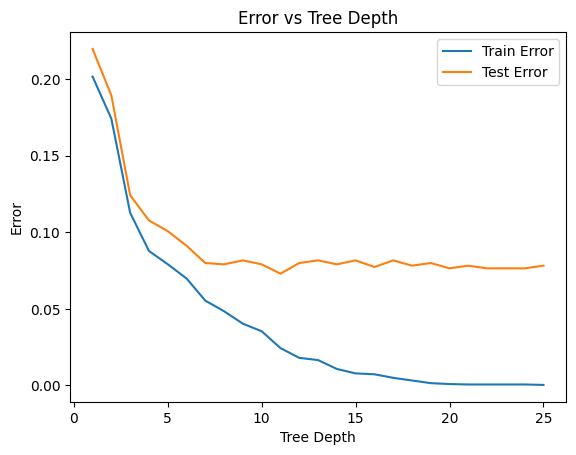

In [24]:
plt.plot(depths, train_errors, label = "Train Error")
plt.plot(depths, test_errors, label = "Test Error")

plt.xlabel("Tree Depth")
plt.ylabel("Error")
plt.title("Error vs Tree Depth")

plt.legend()
plt.show()

## Problem 2

### Part 1

In [25]:
T_values = [10, 50, 100, 500]

In [26]:
train_acc_rf = []
test_acc_rf = []

train_f1_rf = []
test_f1_rf = []

train_auc_rf = []
test_auc_rf = []

In [27]:
for T in T_values:
    rf_model = RandomForestClassifier(n_estimators = T, random_state = 42)
    rf_model.fit(X_train, y_train)

    y_train_pred_rf = rf_model.predict(X_train)
    y_test_pred_rf = rf_model.predict(X_test)

    y_train_prob_rf = rf_model.predict_proba(X_train)[:, 1]
    y_test_prob_rf = rf_model.predict_proba(X_test)[:, 1]

    train_acc_rf.append(accuracy_score(y_train, y_train_pred_rf))
    test_acc_rf.append(accuracy_score(y_test, y_test_pred_rf))

    train_f1_rf.append(f1_score(y_train, y_train_pred_rf))
    test_f1_rf.append(f1_score(y_test, y_test_pred_rf))

    train_auc_rf.append(roc_auc_score(y_train, y_train_prob_rf))
    test_auc_rf.append(roc_auc_score(y_test, y_test_prob_rf))

In [28]:
for i in range(len(T_values)):
    print(f"T = {T_values[i]}")
    print(f"Train Accuracy: {train_acc_rf[i]:.4f}")
    print(f"Test Accuracy:  {test_acc_rf[i]:.4f}")
    print(f"Train F1:       {train_f1_rf[i]:.4f}")
    print(f"Test F1:        {test_f1_rf[i]:.4f}")
    print(f"Train AUC:      {train_auc_rf[i]:.4f}")
    print(f"Test AUC:       {test_auc_rf[i]:.4f}")
    print()

T = 10
Train Accuracy: 0.9971
Test Accuracy:  0.9418
Train F1:       0.9963
Test F1:        0.9241
Train AUC:      1.0000
Test AUC:       0.9772

T = 50
Train Accuracy: 0.9997
Test Accuracy:  0.9470
Train F1:       0.9996
Test F1:        0.9311
Train AUC:      1.0000
Test AUC:       0.9852

T = 100
Train Accuracy: 0.9997
Test Accuracy:  0.9513
Train F1:       0.9996
Test F1:        0.9371
Train AUC:      1.0000
Test AUC:       0.9859

T = 500
Train Accuracy: 0.9997
Test Accuracy:  0.9513
Train F1:       0.9996
Test F1:        0.9368
Train AUC:      1.0000
Test AUC:       0.9863



### Part 3

In [29]:
rf = RandomForestClassifier(n_estimators = 100, random_state = 42)

In [30]:
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [31]:
importances = rf.feature_importances_

In [32]:
indices = np.argsort(importances)[::-1]
for i in range(len(importances)):
    print(f"Feature {indices[i]}: {importances[indices[i]]:.5f}")

Feature 51: 0.11648
Feature 52: 0.10077
Feature 6: 0.07911
Feature 15: 0.05912
Feature 55: 0.05780
Feature 56: 0.05740
Feature 54: 0.05524
Feature 20: 0.05395
Feature 24: 0.04209
Feature 23: 0.03278
Feature 18: 0.03179
Feature 22: 0.02691
Feature 4: 0.02674
Feature 26: 0.01986
Feature 45: 0.01777
Feature 25: 0.01622
Feature 7: 0.01522
Feature 2: 0.01483
Feature 36: 0.01481
Feature 49: 0.01354
Feature 11: 0.01242
Feature 5: 0.01132
Feature 16: 0.01075
Feature 44: 0.01068
Feature 9: 0.00905
Feature 17: 0.00888
Feature 10: 0.00698
Feature 41: 0.00584
Feature 27: 0.00579
Feature 34: 0.00540
Feature 48: 0.00501
Feature 8: 0.00435
Feature 1: 0.00410
Feature 0: 0.00395
Feature 19: 0.00369
Feature 35: 0.00347
Feature 38: 0.00340
Feature 53: 0.00323
Feature 32: 0.00322
Feature 12: 0.00320
Feature 29: 0.00311
Feature 50: 0.00226
Feature 43: 0.00224
Feature 21: 0.00219
Feature 42: 0.00155
Feature 30: 0.00142
Feature 14: 0.00141
Feature 28: 0.00139
Feature 13: 0.00138
Feature 40: 0.00106
Feature 3

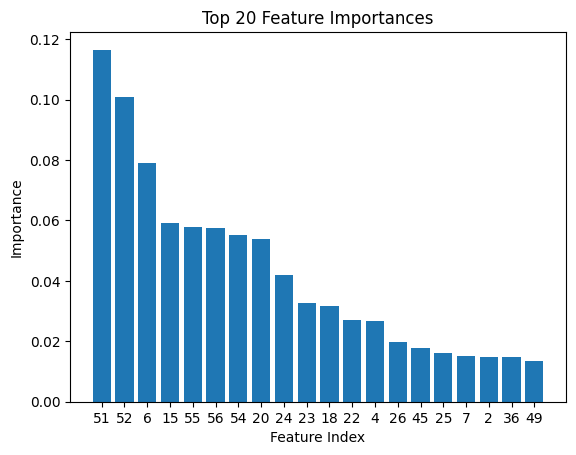

In [33]:
plt.figure()
plt.title("Top 20 Feature Importances")

plt.bar(range(20), importances[indices[:20]])
plt.xticks(range(20), indices[:20])

plt.xlabel("Feature Index")
plt.ylabel("Importance")

plt.show()

## Problem 3

### Part 1

In [34]:
T_values_ada = [10, 50, 100, 500]

In [35]:
train_acc_ada = []
test_acc_ada = []

train_f1_ada = []
test_f1_ada = []

train_auc_ada = []
test_auc_ada = []

In [36]:
for T in T_values_ada:
    base_tree = DecisionTreeClassifier(max_depth = 1, random_state = 42)
    ada_model = AdaBoostClassifier(estimator = base_tree, n_estimators = T, random_state = 42)
    ada_model.fit(X_train, y_train)

    y_train_pred_ada = ada_model.predict(X_train)
    y_test_pred_ada = ada_model.predict(X_test)

    y_train_prob_ada = ada_model.predict_proba(X_train)[:, 1]
    y_test_prob_ada = ada_model.predict_proba(X_test)[:, 1]

    train_acc_ada.append(accuracy_score(y_train, y_train_pred_ada))
    test_acc_ada.append(accuracy_score(y_test, y_test_pred_ada))

    train_f1_ada.append(f1_score(y_train, y_train_pred_ada))
    test_f1_ada.append(f1_score(y_test, y_test_pred_ada))

    train_auc_ada.append(roc_auc_score(y_train, y_train_prob_ada))
    test_auc_ada.append(roc_auc_score(y_test, y_test_prob_ada))

In [37]:
for i in range(len(T_values_ada)):
    print(f"T = {T_values_ada[i]}")
    print(f"Train Accuracy: {train_acc_ada[i]:.4f}")
    print(f"Test Accuracy:  {test_acc_ada[i]:.4f}")
    print(f"Train F1:       {train_f1_ada[i]:.4f}")
    print(f"Test F1:        {test_f1_ada[i]:.4f}")
    print(f"Train AUC:      {train_auc_ada[i]:.4f}")
    print(f"Test AUC:       {test_auc_ada[i]:.4f}")
    print()

T = 10
Train Accuracy: 0.9058
Test Accuracy:  0.8914
Train F1:       0.8807
Test F1:        0.8616
Train AUC:      0.9638
Test AUC:       0.9545

T = 50
Train Accuracy: 0.9348
Test Accuracy:  0.9209
Train F1:       0.9156
Test F1:        0.8976
Train AUC:      0.9814
Test AUC:       0.9762

T = 100
Train Accuracy: 0.9414
Test Accuracy:  0.9314
Train F1:       0.9247
Test F1:        0.9117
Train AUC:      0.9843
Test AUC:       0.9789

T = 500
Train Accuracy: 0.9522
Test Accuracy:  0.9374
Train F1:       0.9387
Test F1:        0.9195
Train AUC:      0.9902
Test AUC:       0.9828



### Part 3

In [38]:
y_prob_dt100 = decisionTree.predict_proba(X_test)[:, 1]

In [39]:
rf_100 = RandomForestClassifier(n_estimators = 100, random_state = 42)
rf_100.fit(X_train, y_train)

y_prob_rf100 = rf_100.predict_proba(X_test)[:, 1]

In [40]:
baseTree = DecisionTreeClassifier(max_depth = 1, random_state = 42)
ada_100 = AdaBoostClassifier(estimator = baseTree, n_estimators = 100, random_state = 42)
ada_100.fit(X_train, y_train)

y_prob_ada100 = ada_100.predict_proba(X_test)[:, 1]

In [41]:
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt100)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf100)
fpr_ada, tpr_ada, _ = roc_curve(y_test, y_prob_ada100)

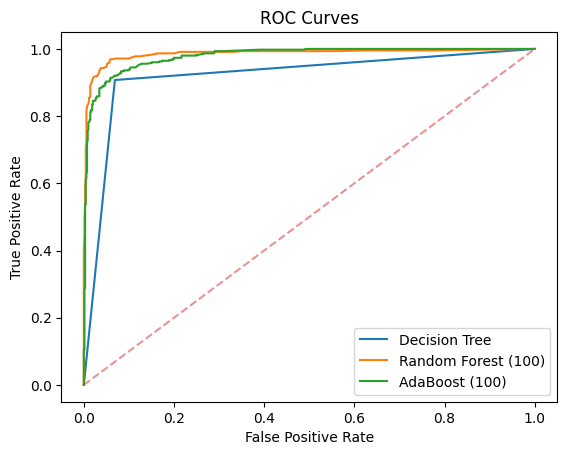

In [43]:
plt.figure()

plt.plot(fpr_dt, tpr_dt, label = "Decision Tree")
plt.plot(fpr_rf, tpr_rf, label = "Random Forest (100)")
plt.plot(fpr_ada, tpr_ada, label = "AdaBoost (100)")

plt.plot([0, 1], [0, 1], linestyle = "--", alpha = 0.5)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")

plt.legend()
plt.show()